# Exploratory Data Analysis Assignment


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

from scipy import stats
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("/content/Cars_data.csv")

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Check Datatypes

In [3]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


## Drop Irrelevant Columns

In [4]:
cols_to_drop = ["Engine Fuel Type", "Market Category",
                "Vehicle Style", "Popularity",
                "Number of Doors", "Vehicle Size"]

df = df.drop(cols_to_drop, axis=1)

df.head()

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


## Rename Columns

In [5]:
rename_cols = {
    "Engine HP":"HP",
    "Engine Cylinders":"Cylinders",
    "Transmission Type":"Transmission",
    "Driven_Wheels":"Drive Mode",
    "highway MPG":"MPG-H",
    "city mpg":"MPG-C",
    "MSRP":"Price"
}

df = df.rename(columns=rename_cols)

df.head()

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


## Remove Duplicate Rows

In [6]:
print(df.shape)

df = df.drop_duplicates()

print(df.shape)

(11914, 10)
(10925, 10)


## Check Missing Values

In [7]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
HP,69
Cylinders,30
Transmission,0
Drive Mode,0
MPG-H,0
MPG-C,0
Price,0


## Drop Missing Values

In [8]:
df = df.dropna()

df.isnull().sum()

,0
Make,0
Model,0
Year,0
HP,0
Cylinders,0
Transmission,0
Drive Mode,0
MPG-H,0
MPG-C,0
Price,0


## Statistical Summary

In [9]:
df.describe()

,Year,HP,Cylinders,MPG-H,MPG-C,Price
count,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,1.082700e+04
mean,2010.896370,254.553062,5.691604,26.308119,19.327607,4.249325e+04
std,7.029534,109.841537,1.768551,7.504652,6.643567,6.229451e+04
min,1990.000000,55.000000,0.000000,12.000000,7.000000,2.000000e+03
25%,2007.000000,173.000000,4.000000,22.000000,16.000000,2.197250e+04
50%,2015.000000,240.000000,6.000000,25.000000,18.000000,3.084500e+04
75%,2016.000000,303.000000,6.000000,30.000000,22.000000,4.330000e+04
max,2017.000000,1001.000000,16.000000,354.000000,137.000000,2.065902e+06


## Boxplot for Price

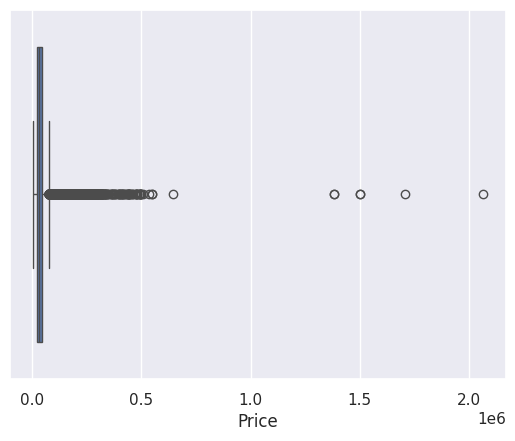

In [10]:
sns.boxplot(x=df['Price'])

plt.show()

## Boxplot for HP

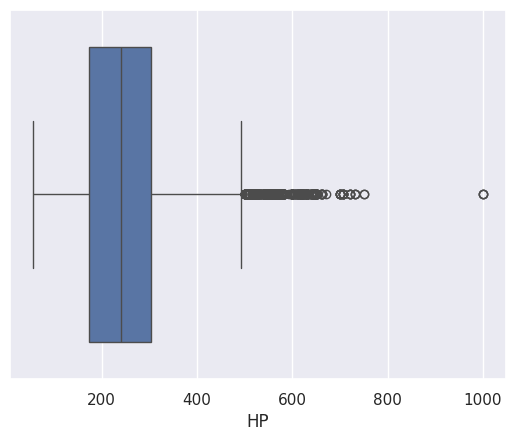

In [11]:
sns.boxplot(x=df['HP'])

plt.show()

## Numeric Columns

In [12]:
print(df.loc[:, (df.dtypes=='int64') | (df.dtypes=='float64')].columns)

Index(['Year', 'HP', 'Cylinders', 'MPG-H', 'MPG-C', 'Price'], dtype='object')


## Save Numeric Columns in List

In [13]:
l = df.loc[:, (df.dtypes=='int64') | (df.dtypes=='float64')].columns.tolist()

print(l)

['Year', 'HP', 'Cylinders', 'MPG-H', 'MPG-C', 'Price']


## IQR Method

In [14]:
Q1 = df[l].quantile(0.25)
Q3 = df[l].quantile(0.75)

IQR = Q3 - Q1

df2 = df[~((df[l] < (Q1 - 1.5 * IQR)) |
           (df[l] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(df.shape)
print(df2.shape)

(10827, 10)
(9191, 10)


## Unique Values Count

In [15]:
for i in df.columns:
    print("---------------", i, "---------------")
    print(df[i].value_counts())

--------------- Make ---------------
Make
Chevrolet        1043
Ford              798
Toyota            651
Volkswagen        563
Nissan            540
Dodge             513
GMC               475
Honda             429
Cadillac          396
Mazda             392
Mercedes-Benz     340
Suzuki            338
Infiniti          326
BMW               324
Audi              320
Hyundai           254
Acura             246
Volvo             241
Subaru            229
Kia               219
Mitsubishi        202
Lexus             201
Chrysler          185
Buick             184
Pontiac           163
Lincoln           152
Porsche           134
Land Rover        126
Oldsmobile        111
Saab              101
Aston Martin       91
Bentley            74
Ferrari            69
Plymouth           62
Scion              60
FIAT               58
Maserati           55
Lamborghini        52
Rolls-Royce        31
Lotus              28
HUMMER             17
Maybach            16
Alfa Romeo          5
McLaren     

## Distplot for HP

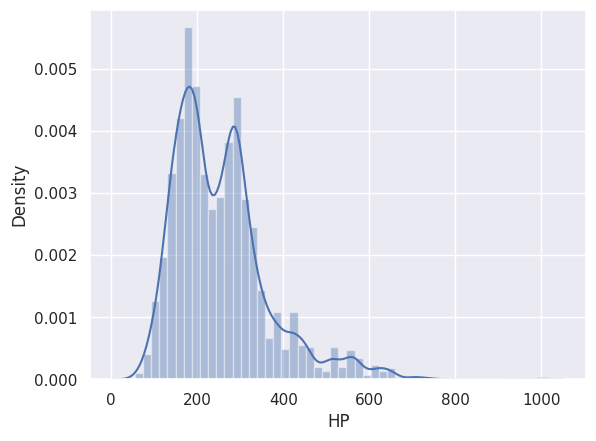

In [16]:
sns.distplot(df['HP'])

plt.show()

## Subplots

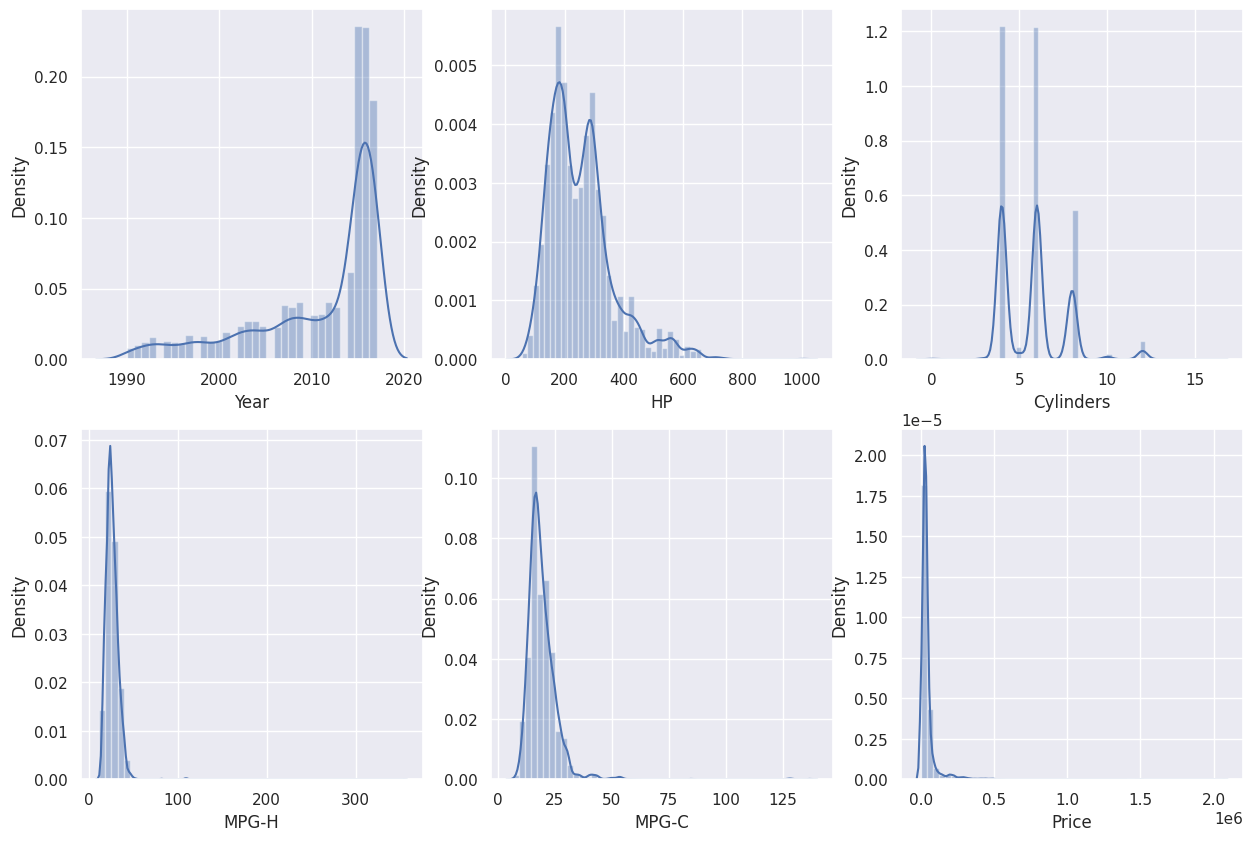

In [17]:
c = 0

plt.figure(figsize=(15,10))

for i in l:

    c = c + 1

    plt.subplot(2,3,c)

    sns.distplot(df[i])

plt.show()

## Bar Plot

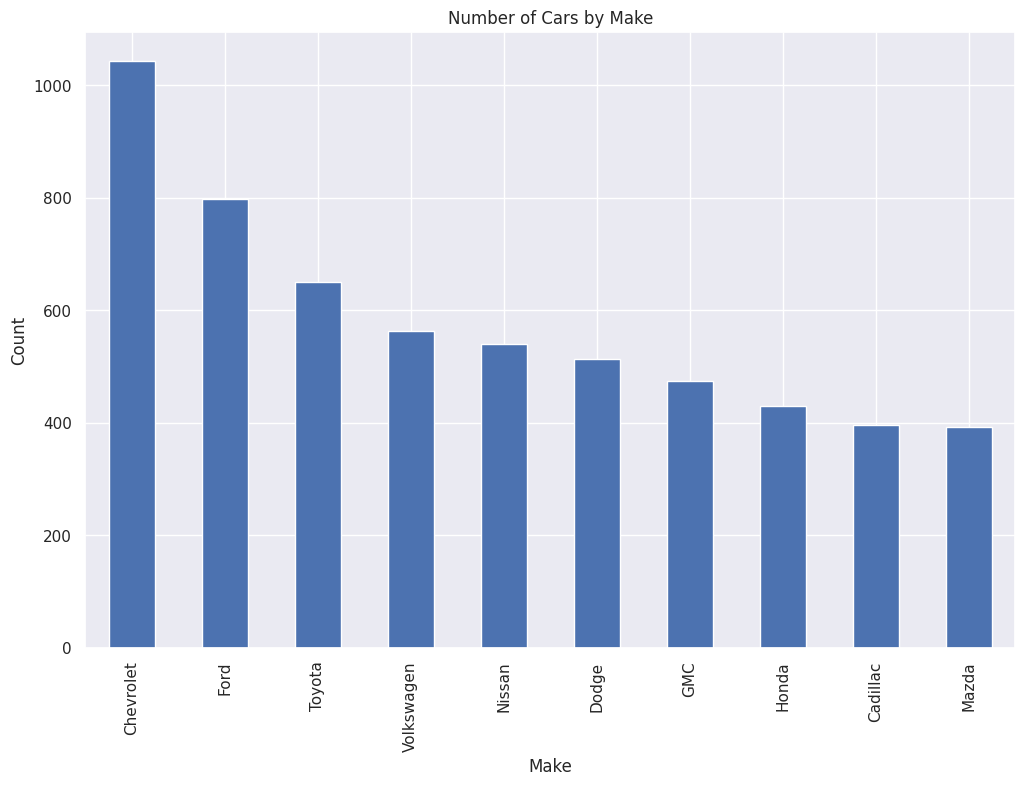

In [18]:
plt.figure(figsize=(12,8))

df['Make'].value_counts().nlargest(10).plot(kind='bar')

plt.title("Number of Cars by Make")

plt.xlabel("Make")

plt.ylabel("Count")

plt.show()

## Countplot

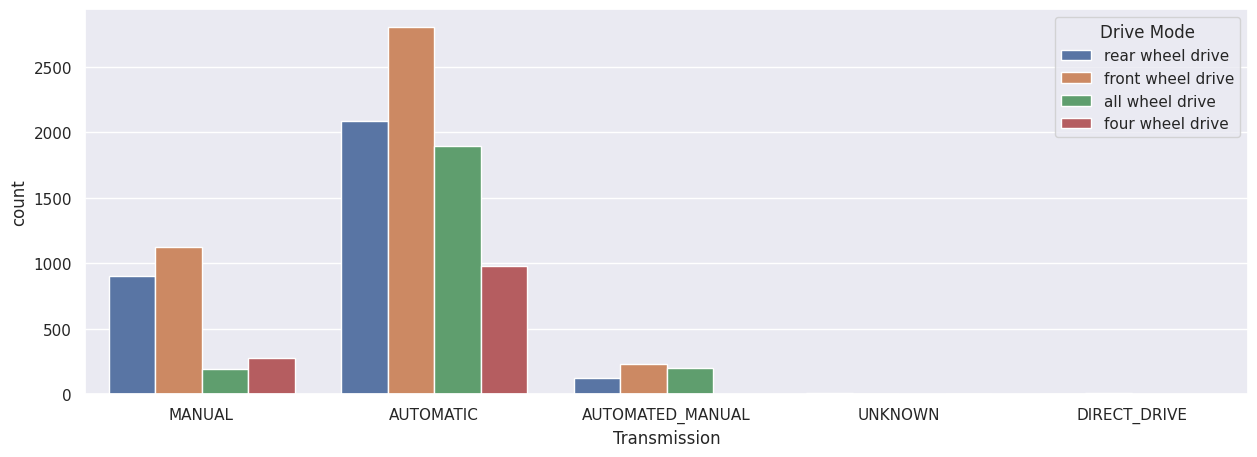

In [19]:
plt.figure(figsize=(15,5))

sns.countplot(x='Transmission', hue='Drive Mode', data=df)

plt.show()

## Scatterplot

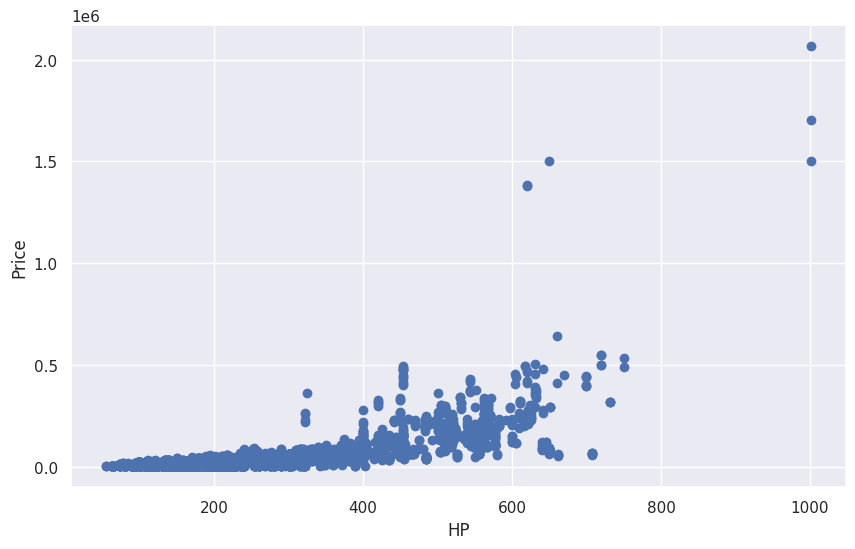

In [20]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(df['HP'], df['Price'])

ax.set_xlabel('HP')

ax.set_ylabel('Price')

plt.show()

## Barplot between Cylinders and Price

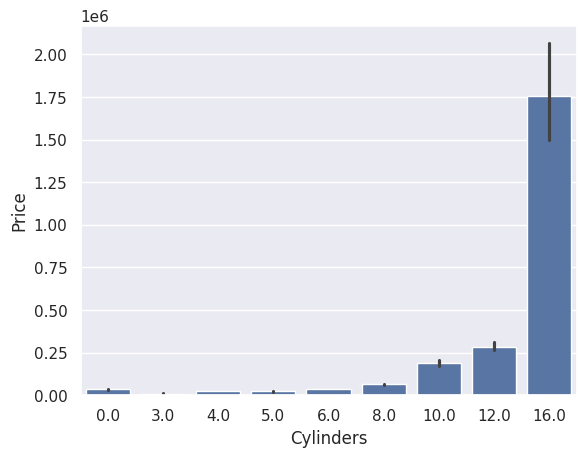

In [21]:
sns.barplot(x='Cylinders', y='Price', data=df)

plt.show()

## Transmission Plot

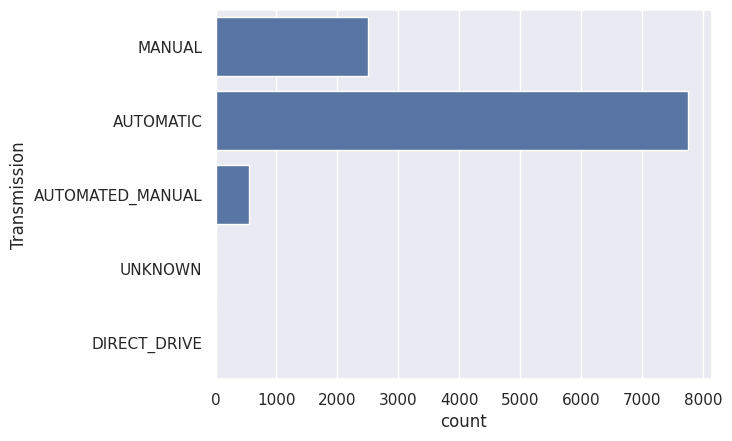

In [22]:
sns.countplot(y='Transmission', data=df)

plt.show()

## Correlation Matrix

In [23]:
corr = df.corr(numeric_only=True)

print(corr)

               Year        HP  Cylinders     MPG-H     MPG-C     Price
Year       1.000000  0.314971  -0.050598  0.284237  0.234135  0.196789
HP         0.314971  1.000000   0.788007 -0.420281 -0.473551  0.659835
Cylinders -0.050598  0.788007   1.000000 -0.611576 -0.632407  0.554740
MPG-H      0.284237 -0.420281  -0.611576  1.000000  0.841229 -0.209150
MPG-C      0.234135 -0.473551  -0.632407  0.841229  1.000000 -0.234050
Price      0.196789  0.659835   0.554740 -0.209150 -0.234050  1.000000


## Heatmap

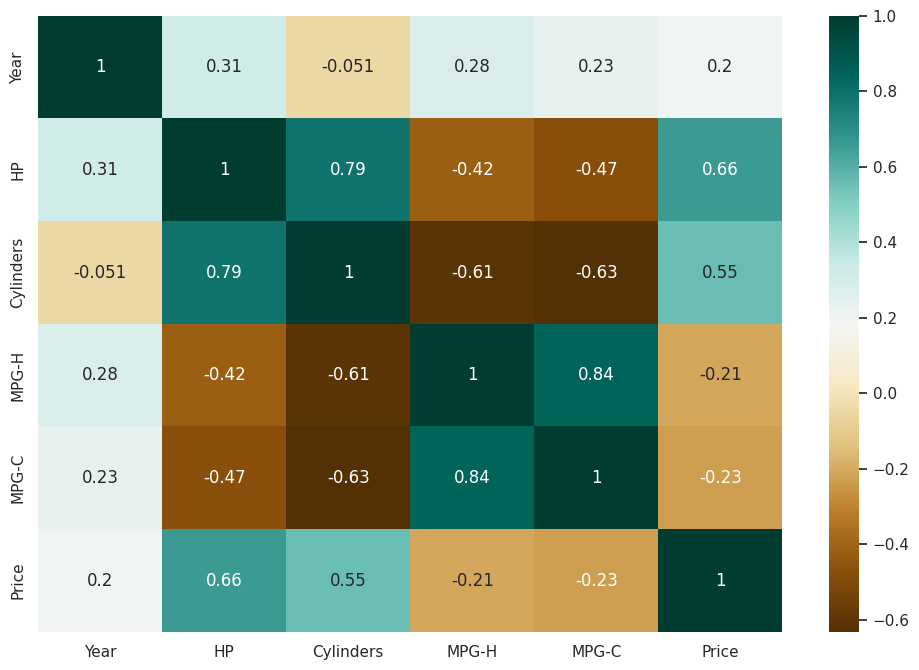

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap='BrBG', annot=True)

plt.show()